In [12]:
from libraries import*
from O17_simulation_NMR import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gama, QPAS, QXG, CSQXG, CsaQXG, Nptx, AcsQXG
from functions import fourier3, fourier5, Rabc, Quad, ChemShift
import sympy as sym
sym.init_printing()

**Read Data**

In [13]:
titles = ['x rotation', 'y rotation', 'z rotation']
df = [0]*len(titles)

file_path = ('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_simulation/')

for i, orientation in enumerate(titles):
    file_name = f'{orientation}_O17.csv'
    df[i] = pd.read_csv(file_path+file_name, index_col=0)


**Find H_Q(2) Tensor Components**

In [14]:
df_Q = [0]*3
for i in range(len(titles)):
    df_Q[i] = 3*df[i].freq5232 + 3*df[i].freq3252 + df[i].freq3212 + df[i].freq1232 - 8*df[i].freq1212 #from equation in Rotating Frame hamiltonian_32_52 word document
            

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.497e-18 (chi2/ndof = 0.0)│              Nfcn = 168              │
│ EDM = 6.96e-19 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

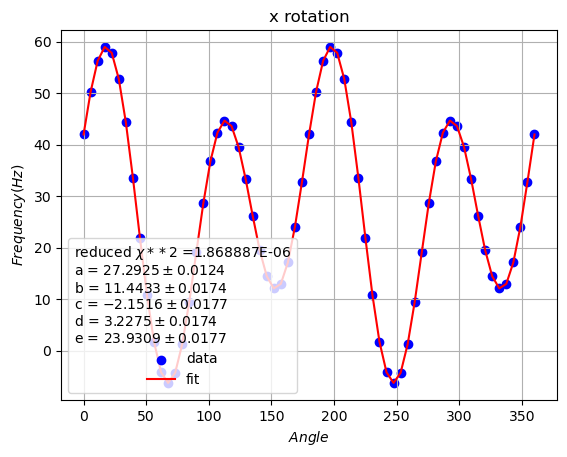

a = 27.29255854467379
b = 11.44338433051461
c = -2.151624089883373
d = 3.2273967708095217
e = 23.930997941579722
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.031e-18 (chi2/ndof = 0.0)│              Nfcn = 177              │
│ EDM = 2.53e-26 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴───

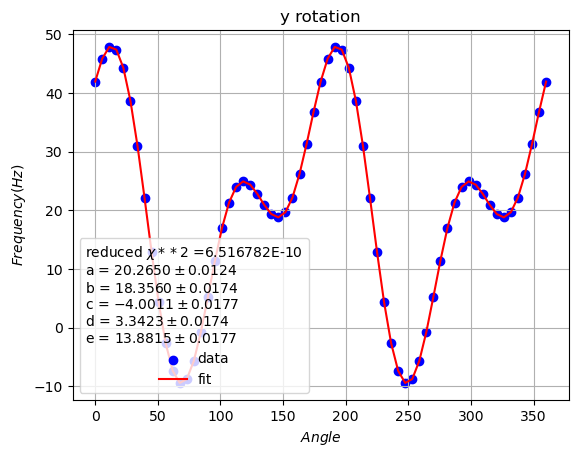

a = 20.26504661352198
b = 18.355977599698207
c = -4.001122319291652
d = 3.342315432772206
e = 13.88148742353488
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.354e-19 (chi2/ndof = 0.0)│              Nfcn = 177              │
│ EDM = 1.55e-26 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴────

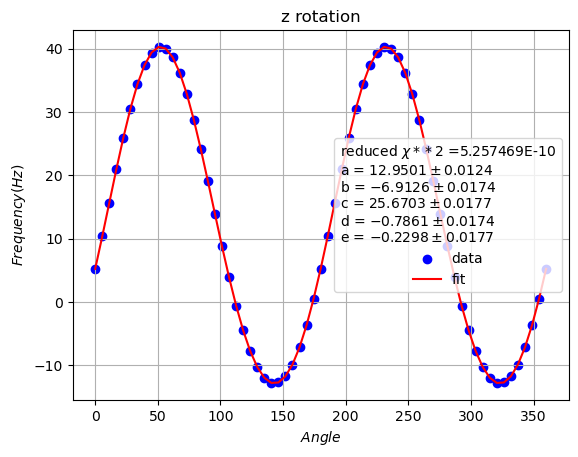

a = 12.950067995881838
b = -6.91259326917498
c = 25.67032366876613
d = -0.7860902801068204
e = -0.2298373239519139


In [15]:
m_Q = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].angle, df_Q[i], 0.1,fourier5)
    
    m_Q[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_Q[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_Q[i].fval / (len(df[i].angle) - m_Q[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_Q[i].parameters, m_Q[i].values, m_Q[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_Q[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, df_Q[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier5(df[i].angle, *m_Q[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_Q[i].parameters, m_Q[i].values):
        print(f"{key} = {value}")

In [5]:
a_Q = [0]*3; 
b_Q = [0]*3; 
c_Q = [0]*3; 
d_Q = [0]*3
e_Q = [0]*3

par_Q = [a_Q, b_Q, c_Q, d_Q, e_Q]
for i in range(0,3):
    for k in range(len(par_Q)):
        par_Q[k][i] = m_Q[i].values[k]
Dx = d_Q[0]*wX*800;
Ex = e_Q[0]*wX*800;

Dy = d_Q[1]*wX*800;
Ey = e_Q[1]*wX*800;

Dz = d_Q[2]*wX*800;
Ez = e_Q[2]*wX*800;


Gyz2 = (Dx + sqrt(Dx**2+Ex**2))/663;
Gyz_Q = -sqrt(Gyz2); 
GzzmGyy = (4*Ex/1326)*(1/Gyz_Q);

# print(Gyz_Q)

Gxz2 = (Dy + sqrt(Dy**2+Ey**2))/663;
Gxz_Q = sqrt(Gxz2);
GzzmGxx = -(4*Ey/1326)*(1/Gxz_Q);

# print(Gxz_Q)

Gxy2 = (Dz + sqrt(Dz**2+Ez**2))/663;
Gxy_Q = sqrt(Gxy2);
GxxmGyy = (4*Ez/1326)*(1/Gxy_Q);

# print(Gxy_Q)

Gzz1 = (GzzmGyy + GzzmGxx)/3
Gyy1 = Gzz1 -GzzmGyy
Gxx1 = Gzz1 -GzzmGxx

Gxx2 = (GxxmGyy-GzzmGxx)/3
Gzz2 = Gxx2+GzzmGxx
Gyy2 = Gxx2-GxxmGyy

Gyy3 = -(GzzmGyy + GxxmGyy)/3
Gzz3 = Gyy3 + GzzmGyy
Gxx3 = Gyy3 + GxxmGyy

Gxx_Q = (Gxx1+Gxx2+Gxx3)/3;
Gyy_Q = (Gyy1+Gyy2+Gyy3)/3;
Gzz_Q = (Gzz1+Gzz2+Gzz3)/3;

# print(Gxx, Gyy, Gzz)

QXG_f = np.zeros((3, 3))                                #Fit tensor
QXG_f[0,0]=Gxx_Q; QXG_f[0,1]=Gxy_Q; QXG_f[0,2]=Gxz_Q;
QXG_f[1,0]=Gxy_Q; QXG_f[1,1]=Gyy_Q; QXG_f[1,2]=Gyz_Q;
QXG_f[2,0]=Gxz_Q; QXG_f[2,1]=Gyz_Q; QXG_f[2,2]=Gzz_Q;

QXG_f = -QXG_f;

print('Input Quadrupolar Tensor:\n', QXG)
print('Calculated Quad Tensor:\n',QXG_f)

Input Quadrupolar Tensor:
 [[-14939.35113459  -1992.77780677 -46110.24547483]
 [ -1992.77780677 -42772.87109591  57473.23241664]
 [-46110.24547483  57473.23241664  57712.22223051]]
Calculated Quad Tensor:
 [[-14939.35113458  -1992.77780677 -46110.24547484]
 [ -1992.77780677 -42772.87109592  57473.23241665]
 [-46110.24547484  57473.23241665  57712.2222305 ]]


In [6]:
AQ = [0]*3
BQ = [0]*3
CQ = [0]*3
DQ = [0]*3
EQ = [0]*3
AQ[0] = 11.25*(Gzz_Q+Gyy_Q)**2 + 10.625*(Gzz_Q-Gyy_Q)**2 + 50*Gxz_Q**2 + 50*Gxy_Q**2 + 42.5*Gyz_Q**2;
BQ[0] = -7.5*(Gzz_Q**2-Gyy_Q**2) + 30*Gxz_Q**2 - 30*Gxy_Q**2;
CQ[0] = 15*Gyz_Q*(Gzz_Q+Gyy_Q) - 60*Gxz_Q*Gxy_Q;
DQ[0] = -9.375*(Gzz_Q-Gyy_Q)**2 + 37.5*Gyz_Q**2;
EQ[0] = 37.5*Gyz_Q*(Gzz_Q-Gyy_Q);

AQ[1] = 11.25*(Gzz_Q+Gxx_Q)**2 + 10.625*(Gzz_Q-Gxx_Q)**2 + 50*Gyz_Q**2+ 50*Gxy_Q**2 + 42.5*Gxz_Q**2;
BQ[1] = -7.5*(Gzz_Q**2-Gxx_Q**2) + 30*Gyz_Q**2 - 30*Gxy_Q**2;
CQ[1] = -15*Gxz_Q*(Gzz_Q+Gxx_Q) + 60*Gyz_Q*Gxy_Q;
DQ[1] = -9.375*(Gzz_Q-Gxx_Q)**2 + 37.5*Gxz_Q**2;
EQ[1] = -37.5*Gxz_Q*(Gzz_Q-Gxx_Q);

AQ[2] = 11.25*(Gxx_Q+Gyy_Q)**2 + 10.625*(Gxx_Q-Gyy_Q)**2 + 50*Gxz_Q**2 + 50*Gyz_Q**2 + 42.5*Gxy_Q**2;
BQ[2] = -7.5*(Gxx_Q**2-Gyy_Q**2) + 30*Gxz_Q**2 - 30*Gyz_Q**2;
CQ[2] = 15*Gxy_Q*(Gxx_Q+Gyy_Q) - 60*Gxz_Q*Gyz_Q;
DQ[2] = -9.375*(Gxx_Q-Gyy_Q)**2 + 37.5*Gxy_Q**2;
EQ[2] = 37.5*Gxy_Q*(Gxx_Q-Gyy_Q);

HQ2 = [0]*3
for i in range(0,3):
    HQ2[i] = (AQ[i] + BQ[i]*np.cos(2*df[i].angle*np.pi/180.) + CQ[i]*np.sin(2*df[i].angle*np.pi/180.) + DQ[i]*np.cos(4*df[i].angle*np.pi/180.) + EQ[i]*np.sin(4*df[i].angle*np.pi/180.))/(800*wX)


**Find H_CSA Tensor Components**

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.21e-18 (chi2/ndof = 0.0) │              Nfcn = 93               │
│ EDM = 1.94e-20 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

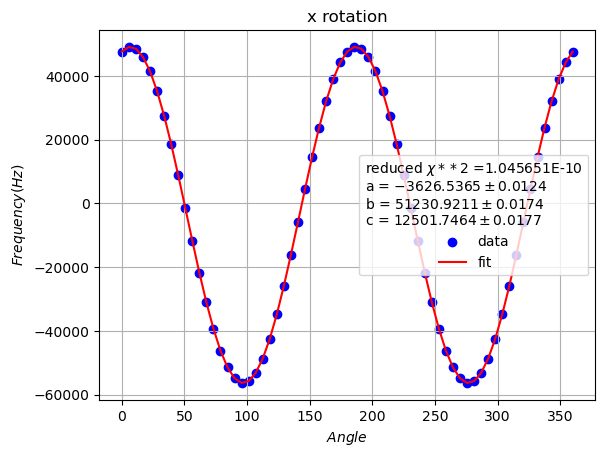

a = -3626.5364990476714
b = 51230.92109504374
c = 12501.746416856276
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.055e-17 (chi2/ndof = 0.0)│              Nfcn = 82               │
│ EDM = 1.87e-19 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────

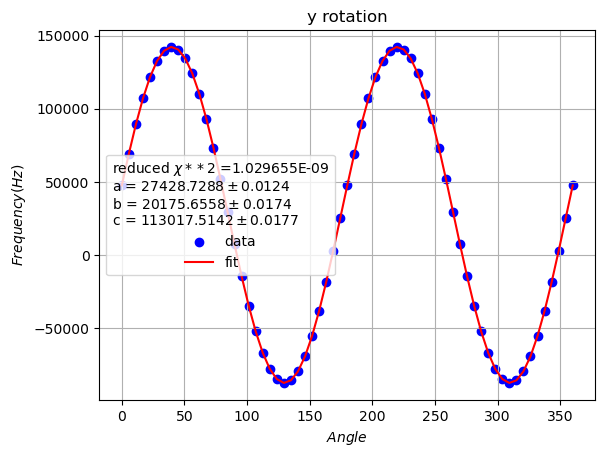

a = 27428.728797045707
b = 20175.655798950367
c = 113017.5141598462
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.359e-18 (chi2/ndof = 0.0)│              Nfcn = 84               │
│ EDM = 1.29e-20 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬────────

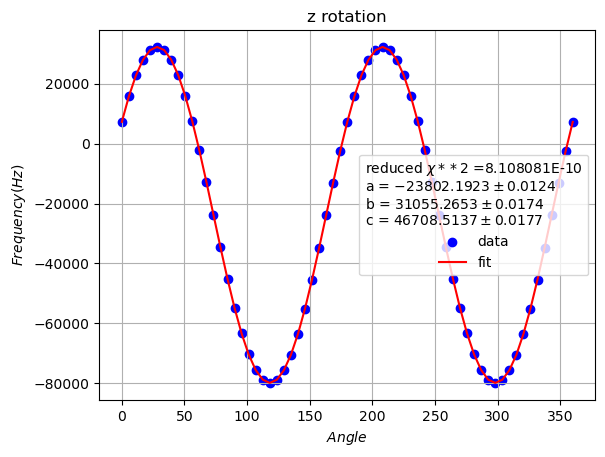

a = -23802.192297998034
b = 31055.265296093366
c = 46708.51370440087


In [7]:
df_CSA = [0]*3
for i in range(0,3):
    df_CSA[i] = np.subtract(df[i].freq_sum, HQ2[i])
m_CSA = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].angle, df_CSA[i], 0.1,fourier3)
    
    m_CSA[i] = Minuit(least_squares, a = 1, b = 1, c= 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_CSA[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_CSA[i].fval / (len(df[i].angle) - m_CSA[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_CSA[i].parameters, m_CSA[i].values, m_CSA[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_CSA[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, df_CSA[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier3(df[i].angle, *m_CSA[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_CSA[i].parameters, m_CSA[i].values):
        print(f"{key} = {value}")


In [8]:
a_csa = [0]*3; 
b_csa = [0]*3; 
c_csa = [0]*3; 

par_csa = [a_csa, b_csa, c_csa]

for i in range(0,3):
    for k in range(len(par_csa)):
        par_csa[k][i] = m_CSA[i].values[k]

Gzz_CSA1 = (a_csa[0]+b_csa[0])/5
Gyy_CSA1 = (a_csa[0]-b_csa[0])/5
Gyz_CSA = -c_csa[0]/5

Gzz_CSA2 = (a_csa[1]+b_csa[1])/5
Gxx_CSA2 = (a_csa[1]-b_csa[1])/5
Gxz_CSA = c_csa[1]/5

Gxx_CSA3 = (a_csa[2]+b_csa[2])/5
Gyy_CSA3 = (a_csa[2]-b_csa[2])/5
Gxy_CSA = -c_csa[2]/5

Gxx_CSA = np.mean([Gxx_CSA2,Gxx_CSA3])
Gyy_CSA = np.mean([Gyy_CSA1,Gyy_CSA3])
Gzz_CSA = np.mean([Gzz_CSA2,Gzz_CSA1])

CsaQXG_f = np.zeros((3, 3))                                             #Fit tensor
CsaQXG_f[0,0]=Gxx_CSA; CsaQXG_f[0,1]=Gxy_CSA; CsaQXG_f[0,2]=Gxz_CSA;
CsaQXG_f[1,0]=Gxy_CSA; CsaQXG_f[1,1]=Gyy_CSA; CsaQXG_f[1,2]=Gyz_CSA;
CsaQXG_f[2,0]=Gxz_CSA; CsaQXG_f[2,1]=Gyz_CSA; CsaQXG_f[2,2]=Gzz_CSA;

print('Input CSA Tensor:\n',CsaQXG_f)
print('Calculated CSA Tensor:\n',CsaQXG)

Input CSA Tensor:
 [[  1450.61459962  -9341.70274088  22603.50283197]
 [ -9341.70274088 -10971.49151882  -2500.34928337]
 [ 22603.50283197  -2500.34928337   9520.8769192 ]]
Calculated CSA Tensor:
 [[  1450.61459962  -9341.70274088  22603.50283197]
 [ -9341.70274088 -10971.49151882  -2500.34928337]
 [ 22603.50283197  -2500.34928337   9520.8769192 ]]


**Find HQ,ACS**

In [9]:
#Finding transition frequencies other  than HQ,ACS
df_mACS = [0]*3

freq5232_ACS = [0]*3
freq3212_ACS = [0]*3
freq1212_ACS = [0]*3
freq1232_ACS = [0]*3
freq3252_ACS = [0]*3

df_QACS = [0]*3

for i in range(3):
    ang = df[0].angle*np.pi/180 # angle from excel file
    atheta = [-ang, ang, np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang ]
    
    theta = atheta[i] 
    phi = aphi[i]
    
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;
    
    #using fit tensor to recalculate frequencies
    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p) 
    R2m1cs, R20cs, R2p1cs = ChemShift(CsaQXG_f,ct, st, s2t, c2t, cp, sp, c2p, s2p)

    #********************change made from original code according to theor415y in next line**************************
    Siso = (Gzz_CSA + Gyy_CSA + Gxx_CSA)/3
    HCSA1 = (Siso + R20cs)                                               
    HQCSA = -(0.5/(2*Ispin*(2*Ispin-1)))*(R2m1Q*R2p1cs+R2p1Q*R2m1cs)/wX;

    HQ1 = 1/(2*Ispin*(2*Ispin-1))*R20Q
    HQ2a= (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m2Q*R2p2Q)/wX                         
    HQ2b = (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m1Q*R2p1Q)/wX

#********************change made from original code according to theory in next line**************************
    freq5232_mACS = 12*(np.real(HQ1) + np.real(HQCSA))  + 1*np.real(HCSA1)+ -8*np.real(HQ2a) + -64*np.real(HQ2b)      # 5/2 <-> 3/2
    freq3212_mACS = 6*(np.real(HQ1) + np.real(HQCSA))  + 1*np.real(HCSA1) + 10*np.real(HQ2a) + 8*np.real(HQ2b)       # 3/2 <-> 1/2
    freq1212_mACS = 0*(np.real(HQ1) + np.real(HQCSA))  + 1*np.real(HCSA1) + 16*np.real(HQ2a) + 32*np.real(HQ2b)     #1/2   <-> -1/2 
    freq1232_mACS = -6*(np.real(HQ1) + np.real(HQCSA)) + 1*np.real(HCSA1) + 10*np.real(HQ2a) + 8*np.real(HQ2b)     #-1/2 <-> -3/2
    freq3252_mACS =  -12*(np.real(HQ1) + np.real(HQCSA)) + 1*np.real(HCSA1) + -8*np.real(HQ2a) + -64*np.real(HQ2b) # -3/2 <-> -5/2                                                                                  

    data = np.column_stack((np.real(freq5232_mACS), np.real(freq3212_mACS), np.real(freq1212_mACS) , np.real(freq1232_mACS),np.real(freq3252_mACS)))
    df_mACS[i]= pd.DataFrame(data, columns=['freq5232_mACS', 'freq3212_mACS', 'freq1212_mACS', 'freq1232_mACS', 'freq3252_mACS'])

    freq5232_ACS[i] = df[i].freq5232 - df_mACS[i].freq5232_mACS
    freq3212_ACS[i] = df[i].freq3212 - df_mACS[i].freq3212_mACS
    freq1212_ACS[i] = df[i].freq1212 - df_mACS[i].freq1212_mACS
    freq1232_ACS[i] = df[i].freq1232 - df_mACS[i].freq1232_mACS
    freq3252_ACS[i] = df[i].freq3252 - df_mACS[i].freq3252_mACS

    df_QACS[i] =  + (freq3212_ACS[i] - freq1232_ACS[i] ) + (freq5232_ACS[i]- freq3252_ACS[i]) #from equation in Rotating Frame hamiltonian_32_52 word document


**Fit HQ,ACS**

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.265e-18 (chi2/ndof = 0.0)│              Nfcn = 105              │
│ EDM = 4.01e-26 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

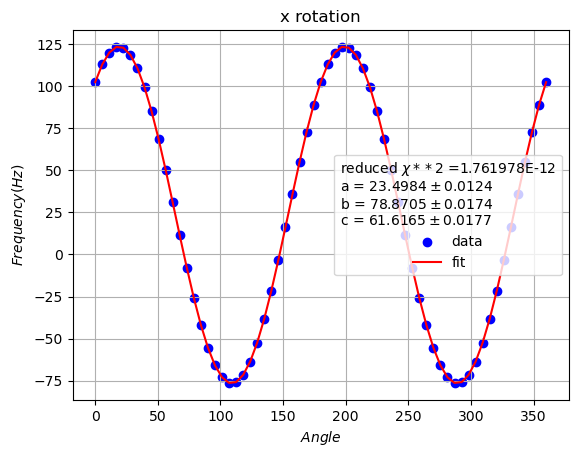

a = 23.498363064140353
b = 78.8705168415332
c = 61.61650231611261
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.475e-18 (chi2/ndof = 0.0)│              Nfcn = 98               │
│ EDM = 2.67e-23 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬──────────

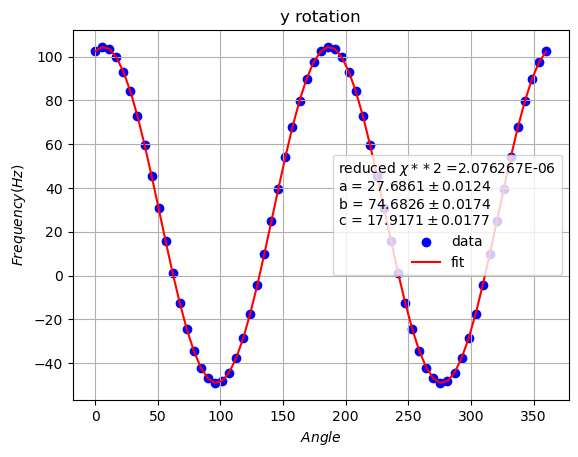

a = 27.686076888691616
b = 74.68280301698289
c = 17.917100819716612
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.56e-19 (chi2/ndof = 0.0) │              Nfcn = 96               │
│ EDM = 1.03e-25 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬────────

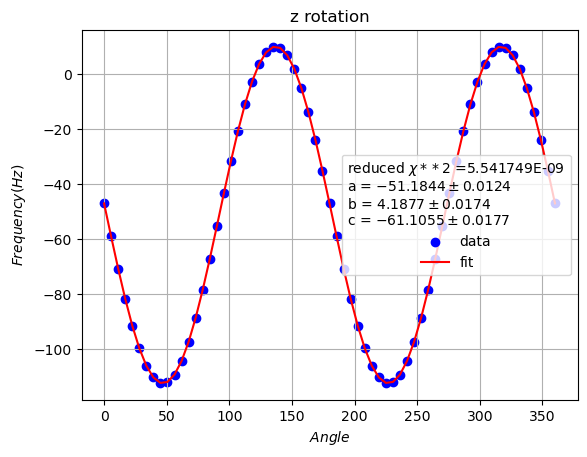

a = -51.18443995283765
b = 4.187713824549929
c = -61.1054547204626


In [10]:
m_QACS = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].angle, df_QACS[i], 0.1,fourier3)
    
    m_QACS[i] = Minuit(least_squares, a = 1, b = 1, c= 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_QACS[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_QACS[i].fval / (len(df[i].angle) - m_QACS[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_QACS[i].parameters, m_QACS[i].values, m_QACS[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_QACS[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, df_QACS[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier3(df[i].angle, *m_QACS[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_QACS[i].parameters, m_QACS[i].values):
        print(f"{key} = {value}")

In [11]:
a_acs = [0]*3; 
b_acs = [0]*3; 
c_acs = [0]*3; 

par_acs = [a_acs, b_acs, c_acs]

for i in range(0,3):
    for k in range(len(par_acs)):
        par_acs[k][i] = m_QACS[i].values[k]

Ax = a_acs[0]*(10/9)*wX
Bx = b_acs[0]*(10/9)*wX
Cx = c_acs[0]*(10/9)*wX

Ay = a_acs[1]*(10/9)*wX
By = b_acs[1]*(10/9)*wX
Cy = c_acs[1]*(10/9)*wX

Az = a_acs[2]*(10/9)*wX
Bz = b_acs[2]*(10/9)*wX
Cz = c_acs[2]*(10/9)*wX

Q_fac_yz = Gxz_Q - (Gxy_Q)**2/Gxz_Q
Q_fac_xz = Gyz_Q - (Gxy_Q)**2/Gyz_Q
Q_fac_xy = Gxz_Q - (Gyz_Q)**2/Gxz_Q

Gyz_ACS1 = (Cx + Ax*Gxy_Q/Gxz_Q + ((Ax - Bx)*Q_fac_yz/(2*Gxy_Q)))/(Gyy_Q - Gzz_Q + Gyz_Q*Q_fac_yz/Gxy_Q)
Gxy_ACS1 = (Bx - Ax + 2*Gyz_Q*Gyz_ACS1)/(2*Gxy_Q)
Gxz_ACS1 = -(Ax + Gxy_Q*Gxy_ACS1)/Gxz_Q

Gxz_ACS2 = (Cy + Ay*Gxy_Q/Gyz_Q - ((Ay - By)*Q_fac_xz/(2*Gxy_Q)))/(Gzz_Q - Gxx_Q - Gxz_Q*Q_fac_xz/Gxy_Q)
Gxy_ACS2 = (-By + Ay - 2*Gxz_Q*Gxz_ACS2)/(2*Gxy_Q)
Gyz_ACS2 = -(Ay - Gxy_Q*Gxy_ACS2)/Gyz_Q

Gxy_ACS3 = (Cz + Az*Gyz_Q/Gxz_Q + ((Az - Bz)*Q_fac_xy/(2*Gyz_Q)))/(Gxx_Q - Gyy_Q - Gxy_Q*Q_fac_xy/Gyz_Q)
Gyz_ACS3 = (-Bz + Az + 2*Gxy_Q*Gxy_ACS3)/(2*Gyz_Q)
Gxz_ACS3 = (Az - Gyz_Q*Gyz_ACS3)/Gxz_Q

# print(Gxz_ACS1, Gxz_ACS2, Gxz_ACS3)

Gxy_ACS = (Gxy_ACS1 + Gxy_ACS2 +  Gxy_ACS3)/3
Gyz_ACS = (Gyz_ACS1 + Gyz_ACS2 +  Gyz_ACS3)/3
Gxz_ACS = (Gxz_ACS1 + Gxz_ACS2 +  Gxz_ACS3)/3
Q_ACS_f = np.zeros((3,3))

Q_ACS_f[0,1] = Gxy_ACS;   Q_ACS_f[0, 2] = Gxz_ACS
Q_ACS_f[1, 0] = -Gxy_ACS; Q_ACS_f[1, 2] = Gyz_ACS
Q_ACS_f[2, 0] = -Gxz_ACS; Q_ACS_f[2, 1] = -Gyz_ACS

print('Input QACS Tensor:\n',AcsQXG)
print('Calculated QACS Tensor:\n',Q_ACS_f)


Input QACS Tensor:
 [[ 2.89337336e-12  3.71578309e+04 -5.82294998e+04]
 [-3.71578309e+04  3.90732043e-12  5.22362035e+04]
 [ 5.82294998e+04 -5.22362035e+04 -2.13388301e-12]]
Calculated QACS Tensor:
 [[     0.          38468.23928934 -58286.13261963]
 [-38468.23928934      0.          52190.76752364]
 [ 58286.13261963 -52190.76752364      0.        ]]
